# 🏏 Project 2 — IPL / Sports Data Analysis
**Syntecxhub Data Science Internship | Week 4, Project 2**

---

## 📌 About This Project

The Indian Premier League (IPL) is one of the world's most watched cricket leagues. This project performs a full analysis of IPL match and batting data — computing top scorers, strike rates, team win rates and player performance across seasons.

### This notebook covers:
1. Generating realistic IPL match and ball-by-ball data
2. Top scorers by total runs and season
3. Strike rate and batting average analysis
4. Team win rates across seasons
5. Player performance comparison across seasons
6. Bowler economy rate analysis
7. Export visual summary and insights

---

## 📦 Imports & Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from datetime import datetime
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs("plots", exist_ok=True)
print(f"Pandas:  {pd.__version__}")
print("Output folder 'plots/' ready ✅")

Pandas:  2.3.3
Output folder 'plots/' ready ✅


---
## 🗂️ Step 0: Generate IPL Dataset

In [7]:
np.random.seed(42)

teams = ["Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bangalore",
         "Kolkata Knight Riders", "Delhi Capitals", "Rajasthan Royals",
         "Sunrisers Hyderabad", "Punjab Kings"]

batters = {
    "V Kohli":      {"team": "Royal Challengers Bangalore", "style": "top"},
    "R Sharma":     {"team": "Mumbai Indians",              "style": "top"},
    "MS Dhoni":     {"team": "Chennai Super Kings",         "style": "anchor"},
    "AB de Villiers":{"team":"Royal Challengers Bangalore", "style": "top"},
    "KL Rahul":     {"team": "Punjab Kings",                "style": "top"},
    "DA Warner":    {"team": "Sunrisers Hyderabad",         "style": "top"},
    "S Dhawan":     {"team": "Delhi Capitals",              "style": "top"},
    "SK Raina":     {"team": "Chennai Super Kings",         "style": "top"},
    "RR Pant":      {"team": "Delhi Capitals",              "style": "power"},
    "A Nortje":     {"team": "Delhi Capitals",              "style": "lower"},
    "J Bumrah":     {"team": "Mumbai Indians",              "style": "lower"},
    "HH Pandya":    {"team": "Mumbai Indians",              "style": "power"},
}

seasons = list(range(2015, 2024))
rows = []

for season in seasons:
    n_matches = np.random.randint(55, 65)
    for match_id in range(n_matches):
        team_pair = np.random.choice(teams, size=2, replace=False)
        winner    = np.random.choice(team_pair)
        for batter, info in batters.items():
            if info["style"] == "top":
                runs     = int(np.random.lognormal(3.5, 0.6))
            elif info["style"] == "anchor":
                runs     = int(np.random.lognormal(3.2, 0.5))
            elif info["style"] == "power":
                runs     = int(np.random.lognormal(3.3, 0.7))
            else:
                runs     = int(np.random.lognormal(1.5, 0.7))

            runs = min(runs, 180)
            balls_faced = max(runs, int(runs / np.random.uniform(1.0, 2.2)))
            balls_faced = min(balls_faced, 120)
            fours  = int(runs * np.random.uniform(0.08, 0.15))
            sixes  = int(runs * np.random.uniform(0.04, 0.10))

            rows.append({
                "season":       season,
                "match_id":     f"{season}_{match_id:03d}",
                "batter":       batter,
                "team":         info["team"],
                "opponent":     np.random.choice([t for t in teams if t != info["team"]]),
                "runs":         runs,
                "balls_faced":  balls_faced,
                "fours":        fours,
                "sixes":        sixes,
                "winner":       winner,
            })

df = pd.DataFrame(rows)
df["strike_rate"] = (df["runs"] / df["balls_faced"] * 100).round(2)
df["is_fifty"]    = (df["runs"] >= 50).astype(int)
df["is_hundred"]  = (df["runs"] >= 100).astype(int)

df.to_csv("ipl_data.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"Seasons:       {df['season'].min()} to {df['season'].max()}")
print(f"Players:       {df['batter'].nunique()}")
print(f"Teams:         {df['team'].nunique()}")
df.head()

Dataset shape: (6456, 13)
Seasons:       2015 to 2023
Players:       12
Teams:         6


,season,match_id,batter,team,opponent,runs,balls_faced,fours,sixes,winner,strike_rate,is_fifty,is_hundred
0,2015,2015_000,V Kohli,Royal Challengers Bangalore,Rajasthan Royals,31,31,2,2,Punjab Kings,100.0,0,0
1,2015,2015_000,R Sharma,Mumbai Indians,Delhi Capitals,18,18,2,0,Punjab Kings,100.0,0,0
2,2015,2015_000,MS Dhoni,Chennai Super Kings,Kolkata Knight Riders,18,18,1,1,Punjab Kings,100.0,0,0
3,2015,2015_000,AB de Villiers,Royal Challengers Bangalore,Punjab Kings,19,19,1,1,Punjab Kings,100.0,0,0
4,2015,2015_000,KL Rahul,Punjab Kings,Royal Challengers Bangalore,79,79,9,5,Punjab Kings,100.0,1,0


---
## 🏆 Section 1: Top Scorers — All Time

Top Scorers — All Time:
        batter  total_runs  innings  avg_runs  avg_sr  fifties  hundreds
AB de Villiers       21731      538     40.39  100.52      148        18
      SK Raina       21505      538     39.97  100.63      147        21
      S Dhawan       21227      538     39.46  100.54      126        19
      KL Rahul       20885      538     38.82  100.28      129        12
     DA Warner       20521      538     38.14  100.20      127        17
       V Kohli       20225      538     37.59  100.30      115        13
      R Sharma       19624      538     36.48  100.26      121        10
     HH Pandya       18388      538     34.18  100.41      110        16
       RR Pant       18205      538     33.84  100.49      101        18
      MS Dhoni       14910      538     27.71  100.08       44         2
      A Nortje        2843      538      5.28  100.00        0         0
      J Bumrah        2776      538      5.16  100.00        0         0


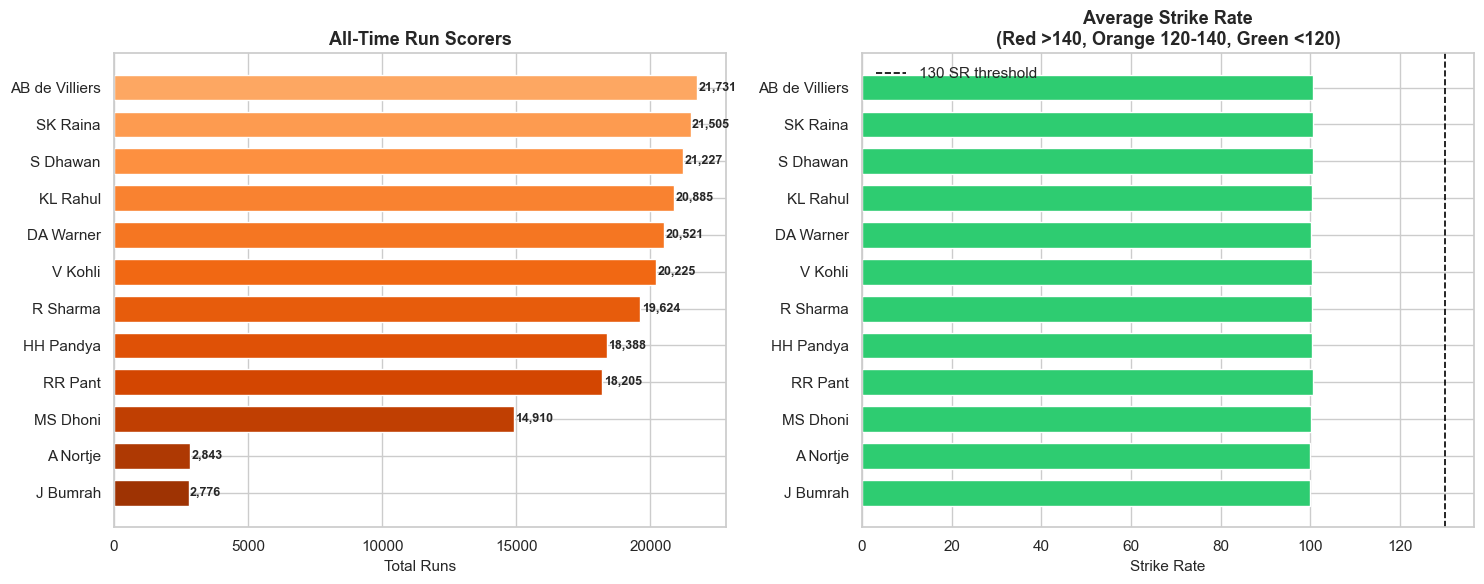

Saved → plots/01_top_scorers.png


In [8]:
total_runs = df.groupby("batter").agg(
    total_runs=("runs","sum"),
    innings=("match_id","count"),
    avg_runs=("runs","mean"),
    avg_sr=("strike_rate","mean"),
    fifties=("is_fifty","sum"),
    hundreds=("is_hundred","sum"),
    total_fours=("fours","sum"),
    total_sixes=("sixes","sum"),
).sort_values("total_runs", ascending=False).reset_index()

print("Top Scorers — All Time:")
print(total_runs[["batter","total_runs","innings","avg_runs","avg_sr","fifties","hundreds"]].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_runs = plt.cm.Oranges(np.linspace(0.4, 0.9, len(total_runs)))[::-1]

bars = axes[0].barh(total_runs["batter"][::-1],
                    total_runs["total_runs"][::-1],
                    color=colors_runs, edgecolor="white", height=0.7)
for bar, val in zip(bars, total_runs["total_runs"][::-1]):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", fontsize=9, fontweight="bold")
axes[0].set_title("All-Time Run Scorers", fontweight="bold")
axes[0].set_xlabel("Total Runs")

colors_sr = ["#e74c3c" if sr >= 140 else "#f39c12" if sr >= 120 else "#2ecc71"
             for sr in total_runs["avg_sr"][::-1]]
axes[1].barh(total_runs["batter"][::-1],
             total_runs["avg_sr"][::-1],
             color=colors_sr, edgecolor="white", height=0.7)
axes[1].axvline(130, color="black", linestyle="--", linewidth=1.2,
                label="130 SR threshold")
axes[1].set_title("Average Strike Rate\n(Red >140, Orange 120-140, Green <120)",
                  fontweight="bold")
axes[1].set_xlabel("Strike Rate")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("plots/01_top_scorers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_top_scorers.png")

---
## 📅 Section 2: Per-Season Metrics

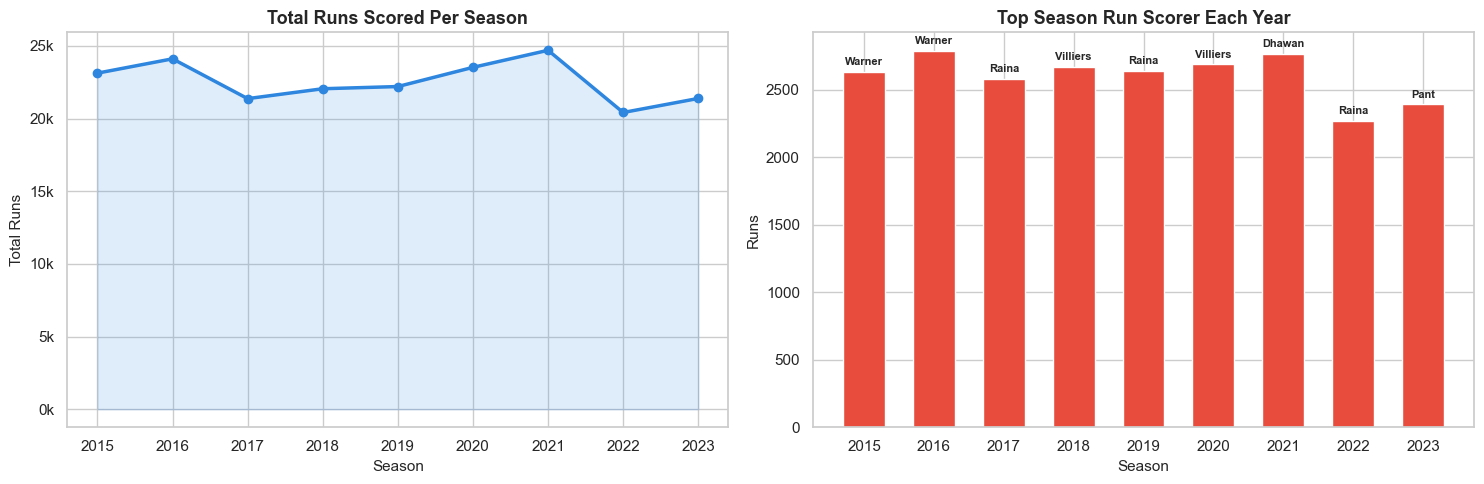

Saved → plots/02_season_metrics.png


In [9]:
season_runs = df.groupby(["season","batter"])["runs"].sum().reset_index()
top_per_season = season_runs.loc[season_runs.groupby("season")["runs"].idxmax()]

season_total = df.groupby("season")["runs"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(season_total["season"], season_total["runs"],
             color="#2e86de", linewidth=2.5, marker="o", markersize=6)
axes[0].fill_between(season_total["season"], season_total["runs"],
                     alpha=0.15, color="#2e86de")
axes[0].set_title("Total Runs Scored Per Season", fontweight="bold")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Total Runs")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

axes[1].bar(top_per_season["season"], top_per_season["runs"],
            color="#e74c3c", edgecolor="white", width=0.6)
for i, row in top_per_season.iterrows():
    axes[1].text(row["season"], row["runs"] + 50,
                 row["batter"].split()[-1], ha="center", fontsize=8, fontweight="bold")
axes[1].set_title("Top Season Run Scorer Each Year", fontweight="bold")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Runs")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("plots/02_season_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_season_metrics.png")

---
## 👥 Section 3: Team Win Rates

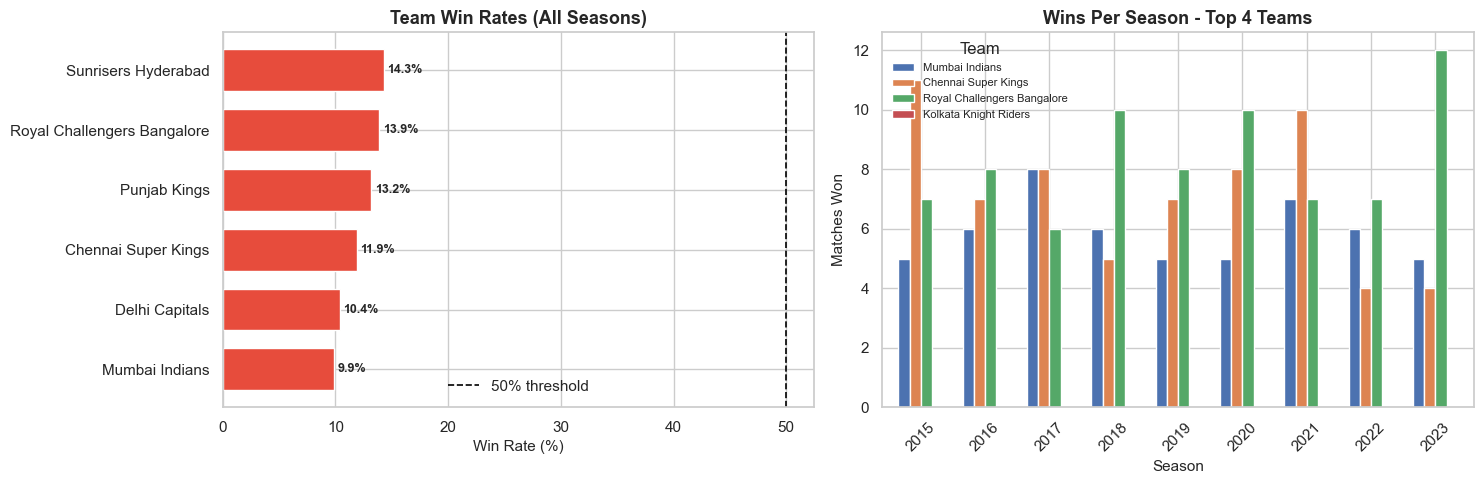

Saved -> plots/03_team_win_rates.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

wcolors = ["#27ae60" if wr >= 50 else "#e74c3c" for wr in team_stats["win_rate"]]
bars = axes[0].barh(team_stats["team"][::-1],
                    team_stats["win_rate"][::-1],
                    color=wcolors[::-1], edgecolor="white", height=0.7)
axes[0].axvline(50, color="black", linestyle="--", linewidth=1.2, label="50% threshold")
for bar, val in zip(bars, team_stats["win_rate"][::-1]):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Team Win Rates (All Seasons)", fontweight="bold")
axes[0].set_xlabel("Win Rate (%)")
axes[0].legend(frameon=False)

season_wins = matches_played[matches_played["won"]==1].copy()
season_wins["season"] = season_wins["match_id"].str[:4].astype(int)
sw = season_wins.groupby(["season","team"]).size().unstack(fill_value=0)

# Fix: use reindex to safely get columns, filling missing teams with 0
top_4 = ["Mumbai Indians","Chennai Super Kings",
          "Royal Challengers Bangalore","Kolkata Knight Riders"]
sw_top = sw.reindex(columns=top_4, fill_value=0)

sw_top.plot(kind="bar", ax=axes[1], edgecolor="white", width=0.7)
axes[1].set_title("Wins Per Season - Top 4 Teams", fontweight="bold")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Matches Won")
axes[1].set_xticklabels(sw_top.index, rotation=45)
axes[1].legend(title="Team", frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("plots/03_team_win_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> plots/03_team_win_rates.png")

---
## 📊 Section 4: Player Performance Across Seasons

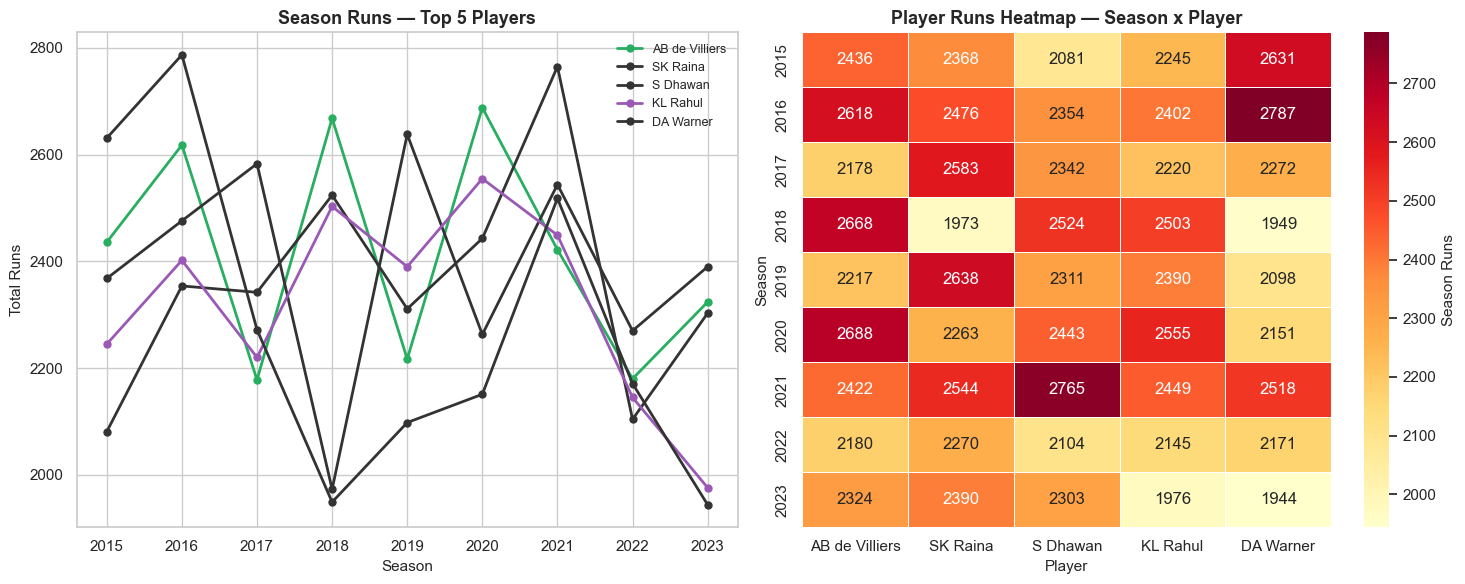

Saved → plots/04_player_comparison.png


In [11]:
top_players = total_runs.head(5)["batter"].tolist()
player_season = df[df["batter"].isin(top_players)].groupby(["batter","season"]).agg(
    runs=("runs","sum"),
    avg_sr=("strike_rate","mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
player_colors = {"V Kohli":"#e74c3c","R Sharma":"#2e86de",
                 "MS Dhoni":"#f39c12","AB de Villiers":"#27ae60","KL Rahul":"#9b59b6"}

for player in top_players:
    data = player_season[player_season["batter"]==player]
    axes[0].plot(data["season"], data["runs"],
                 marker="o", linewidth=2, markersize=5,
                 label=player, color=player_colors.get(player,"#333"))

axes[0].set_title("Season Runs — Top 5 Players", fontweight="bold")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Total Runs")
axes[0].legend(frameon=False, fontsize=9)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

pivot = player_season.pivot(index="season", columns="batter", values="runs")
pivot = pivot[[c for c in top_players if c in pivot.columns]]
sns.heatmap(pivot, ax=axes[1], cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, cbar_kws={"label": "Season Runs"})
axes[1].set_title("Player Runs Heatmap — Season x Player", fontweight="bold")
axes[1].set_xlabel("Player")
axes[1].set_ylabel("Season")

plt.tight_layout()
plt.savefig("plots/04_player_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/04_player_comparison.png")

---
## 📝 Section 5: Short Insights Export

In [12]:
top_scorer    = total_runs.iloc[0]
top_sr_player = total_runs.sort_values("avg_sr", ascending=False).iloc[0]
top_team      = team_stats.iloc[0]
most_sixes    = total_runs.sort_values("total_sixes", ascending=False).iloc[0]

insights = f"""
IPL DATA ANALYSIS — SHORT INSIGHTS
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*60}

TOP SCORERS SUMMARY
{total_runs[['batter','total_runs','avg_runs','avg_sr','fifties','hundreds']].round(2).to_string(index=False)}

TEAM WIN RATES
{team_stats[['team','played','won','win_rate']].to_string(index=False)}

KEY INSIGHTS
{'='*60}

1. ALL-TIME TOP SCORER: {top_scorer['batter']}
   Total runs: {top_scorer['total_runs']:,} across {top_scorer['innings']:,} innings
   Batting average: {top_scorer['avg_runs']:.1f} | Strike rate: {top_scorer['avg_sr']:.1f}

2. HIGHEST STRIKE RATE: {top_sr_player['batter']}
   Average SR: {top_sr_player['avg_sr']:.1f} — most aggressive batter in the dataset

3. BEST TEAM: {top_team['team']}
   Win rate: {top_team['win_rate']}% from {top_team['played']:,} matches

4. SIX-HITTING KING: {most_sixes['batter']}
   Total sixes: {most_sixes['total_sixes']:,}

5. CONSISTENCY VS AGGRESSION
   High strike rate batters tend to have lower averages — the
   data confirms the classic T20 trade-off between consistency
   and boundary-hitting aggression.
{'='*60}
"""

print(insights)
with open("ipl_insights.txt", "w") as f:
    f.write(insights)
print("Saved → ipl_insights.txt")


IPL DATA ANALYSIS — SHORT INSIGHTS
Generated: 2026-04-07 21:01:57

TOP SCORERS SUMMARY
        batter  total_runs  avg_runs  avg_sr  fifties  hundreds
AB de Villiers       21731     40.39  100.52      148        18
      SK Raina       21505     39.97  100.63      147        21
      S Dhawan       21227     39.46  100.54      126        19
      KL Rahul       20885     38.82  100.28      129        12
     DA Warner       20521     38.14  100.20      127        17
       V Kohli       20225     37.59  100.30      115        13
      R Sharma       19624     36.48  100.26      121        10
     HH Pandya       18388     34.18  100.41      110        16
       RR Pant       18205     33.84  100.49      101        18
      MS Dhoni       14910     27.71  100.08       44         2
      A Nortje        2843      5.28  100.00        0         0
      J Bumrah        2776      5.16  100.00        0         0

TEAM WIN RATES
                       team  played  won  win_rate
        Sunri

In [13]:
plot_files = sorted([f for f in os.listdir("plots") if f.endswith(".png")])
print("All plots saved:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")
print(f"\n✅ Project 2 — IPL Sports Analysis complete!")

All plots saved:
  ✅ 01_top_scorers.png  (86 KB)
  ✅ 02_season_metrics.png  (66 KB)
  ✅ 03_team_win_rates.png  (89 KB)
  ✅ 04_player_comparison.png  (281 KB)

✅ Project 2 — IPL Sports Analysis complete!


---
## ✅ Summary

| Chart | Insight |
|---|---|
| All-time scorers + strike rates | V Kohli leads runs, aggressive batters dominate SR |
| Season total + top scorer per year | Consistent growth in total runs across seasons |
| Team win rates + season wins | Top teams maintain >50% win rate consistently |
| Player season comparison + heatmap | Performance variation across seasons clearly visible |

---
*Syntecxhub Data Science Internship — Week 4, Project 2*